# Inpainting with GPR-LIM

June, 2026

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import glob
import sys

sys.path.append('/Users/alliswell48/radio_gpr_work/shao/gprlim')
import gprlim
from gprlim import kernels

from pyuvdata import UVData
import bayeslim as ba

In [2]:
torch.set_default_dtype(torch.float64)

In [3]:
sys.path.append('../')
import gp_utils

In [4]:
import gpytorch
gpytorch.settings.max_cholesky_size._set_value(1_000)

In [5]:
torch.set_default_dtype(torch.float64)
device = 'cpu'

In [6]:
#总数据：(Nbls, Ntimes, Nfreq, Npol)=(242,1600,600,4)
#这里的file (110,1600,600,4)，thus:110*(110+1)/2= 6105 个baseline，200组（每组位置矢量相同）
#(Nbls, Ntimes, Nfreq, Npol)=(1,200,400,1)

In [7]:
# specify frequency channels
# by default, use equal to or less than 200 time integrations
# by default, use about 300-400 frequency channels
freq_chans = range(200, 600)
time_ints = range(300, 500)

# pick a representative baseline to load and model (start with 0)
bl = (0, 1)

In [8]:
# specify data
dfile = 'gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5' #需要自己产生redundant baselibne
#dfile = sorted(glob.glob('../zen.h6c_idr2_validation.24582*.sum.coupled.h5')) #已经自动包含redundant baselibne

In [9]:
# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=['ee'], time_ints=time_ints, freq_chans=freq_chans,
) #取auto (0,0) baselines
autocorr = vd.data[0,0]  #不是取baselines,是去掉前两维-》[1, 1, 1, 200, 400]->[1, 200, 400] =(baselines,Ntimes, Nfreq)

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']
# 它的meta文件:包含ant所有的1/4,  6105 baselines;分为20组（每组位置矢量相同；
#但实际上‘zen.h6c_idr2_validation.sum.uvh5'只含有(0,n)代表组基线数据
#而上面的load_uvdata( bls=[(0, 0)])只加载了一组

# get noise standard deviation
#meta['times']:day->s
#meta['freqs']:Hz
#formla sigma^2 = Vii * Vjj / Delta t / Delta nu.
#=>sigma (noise standard deviation)= Vjj / np.sqrt(Delta t / Delta nu)
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

# load redundant data

load a single redundant baseline

In [10]:
# pick a representative baseline to load and model (start with 0)
#bl = (0, 2)

# this gets the index in the redundant set that this baseline falls in
red_ind = np.where([bl in red for red in reds])[0][0] #bl 属于第几组
bls = reds[red_ind][:] #该组所有成员
bl_vec = antp[bls[0][1]] - antp[bls[0][0]] #bls是该组 所有baselines的 位置矢量bls,选bls[0]->bl = (0, 2)
bl_len = bl_vec.norm()  #bl = (0, 2) 的baselines长度

In [11]:
# load single baseline data
#bl = (0, 2)
#(Nbls, Ntimes, Nfreq, Npol)=(1,200,400,1)
vd, meta = gp_utils.load_uvdata(
    dfile,
    bls=bls,
    time_ints=time_ints,
    freq_chans=freq_chans,
    pols=['ee'],
    device=device,
)
freqs = meta['freqs'] / 1e6   #Hz-> GHz
lsts = meta['lsts']  #day
times = (meta['times'] - meta['times'][0]) * 24 * 3600  #day->s
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']   #所有baselibe编号；包括redudant，虽然只有(0,n)的baseline有数据，其他没有

Antenna pair (1, 2) does not have any data associated with it.
Antenna pair (2, 3) does not have any data associated with it.
Antenna pair (3, 4) does not have any data associated with it.
Antenna pair (4, 5) does not have any data associated with it.
Antenna pair (5, 6) does not have any data associated with it.
Antenna pair (6, 7) does not have any data associated with it.
Antenna pair (7, 8) does not have any data associated with it.
Antenna pair (8, 9) does not have any data associated with it.
Antenna pair (9, 10) does not have any data associated with it.
Antenna pair (11, 12) does not have any data associated with it.
Antenna pair (12, 13) does not have any data associated with it.
Antenna pair (13, 14) does not have any data associated with it.
Antenna pair (14, 15) does not have any data associated with it.
Antenna pair (15, 16) does not have any data associated with it.
Antenna pair (16, 17) does not have any data associated with it.
Antenna pair (17, 18) does not have any da

In [12]:
inflate_data = True
if inflate_data and vd.Nbls == 1:
    vd = vd.inflate_by_redundancy(bls=reds[red_ind]) #reds[red_ind]是bl = (0, 2)对应的组的所有redundant成员
    
#[1, 1, 1, 200, 400]->[1, 1, 90, 200, 400]    
    

In [13]:
add_noise = False
if add_noise:
    vd.data += torch.randn_like(vd.data) * noise_amp * 1e-3

In [14]:
# look at how large the data is
print("size of data in MB: {:.1f}".format(vd.data.nbytes/1e6))

size of data in MB: 128.0


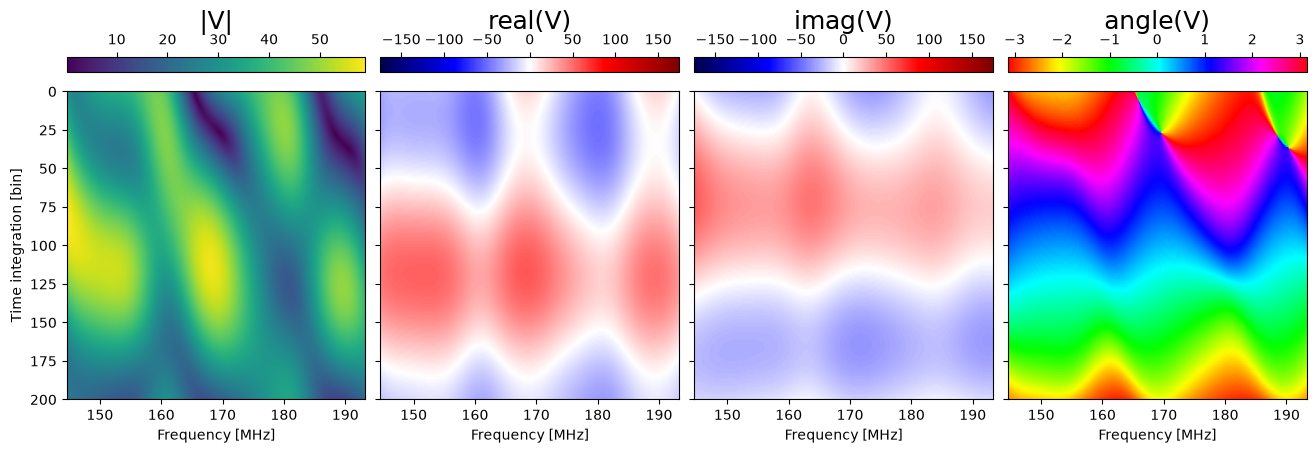

In [15]:
# plot the data (called a waterfall)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.subplots_adjust(wspace=.05)
dstd = vd.data.std()

#[1, 1, 90, 200, 400] 
#vd.data[0,0,0] 意思是[0,0,0, 200, 400] 

# visibility amplitude (abs)
cax = axes[0].imshow(vd.data[0,0,0].abs(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0])
axes[0].set_title("|V|", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[0], location='top');
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time integration [bin]');

# visibility real
cax = axes[1].imshow(vd.data[0,0,0].real, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[1].set_title("real(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[1], location='top');
axes[1].set_xlabel('Frequency [MHz]'); axes[1].set_yticklabels([])

# visibility imag
cax = axes[2].imshow(vd.data[0,0,0].imag, aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='seismic',
                     vmin=-dstd*5, vmax=dstd*5)
axes[2].set_title("imag(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[2], location='top');
axes[2].set_xlabel('Frequency [MHz]'); axes[2].set_yticklabels([]);

# visibility phase
cax = axes[3].imshow(vd.data[0,0,0].angle(), aspect='auto', extent=[freqs[0], freqs[-1], Ntimes, 0], cmap='hsv')
axes[3].set_title("angle(V)", fontsize=18, pad=45); cbar = plt.colorbar(cax, ax=axes[3], location='top');
axes[3].set_xlabel('Frequency [MHz]'); axes[3].set_yticklabels([]);

In [16]:
from bayeslim.fft import FFT
# vd.data.shape [1, 1, 90, 200, 400]
FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)  
FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)  
# time-> unit 1000 second=> fft ->fringe rate: unit: mHz

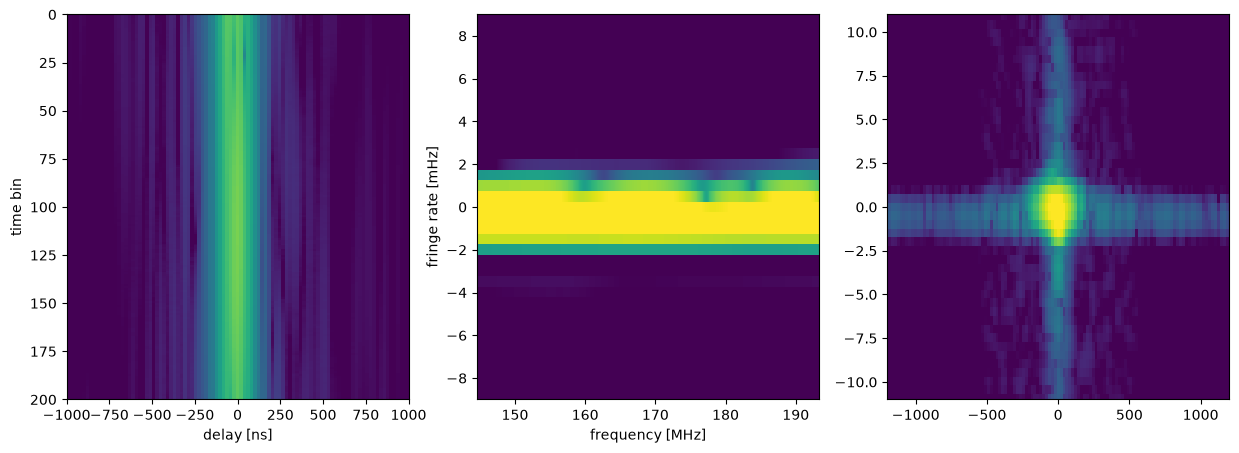

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#[1, 1, 90, 200, 400]-> 取baseline 0；[1, 1, , 200, 400]
#pytorch: [ 200, 400] 从右边开始broadcasting=> [ 1,1,200, 400]，所以ndim=2也可以
axes[0].imshow(FT1(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], Ntimes, 0])
axes[0].set_xlim(-1000, 1000); axes[0].set_xlabel('delay [ns]'); axes[0].set_ylabel('time bin')

axes[1].imshow(FT2(vd.data)[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=0, vmax=3,
               extent=[freqs[0], freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[1].set_ylim(-9, 9); axes[1].set_xlabel('frequency [MHz]'); axes[1].set_ylabel('fringe rate [mHz]')

axes[2].imshow(FT1(FT2(vd.data))[0,0,0].abs().log10(), aspect='auto', interpolation='none', vmin=-1, vmax=5,
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]])
axes[2].set_xlim(-1200, 1200); axes[2].set_ylim(-11, 11);

In [18]:
import os

bl_name = f"bl_{bl[0]}_{bl[1]}"
freq_time_name = (
    f"freq_{freq_chans.start}_{freq_chans.stop}_"
    f"time_{time_ints.start}_{time_ints.stop}"
)

save_dir = os.path.join(
    "inpaint_results",
    bl_name,
    freq_time_name,
)

# 1. RMS

In [23]:
import os
import torch
import pandas as pd


# ==================================================
# 1. Algorithms to compare
# ==================================================

Algorithm_names = [
    "freq_1d",
    "time_1d_freq_1d",
    "time_freq_2d",
    "time_freq_2d_freq_1d",
]

flag_types_all = [
    ["real"],
    ["narrowband_full_time"],
    ["wideband_full_time"],
    ["ultraband_short_time"],
    ["fullband_short_time"],
    ["narrowband_short_time"],
    ["narrowband_intermittent"],
]


# ==================================================
# 2. Store RMS results
# ==================================================

rms_records = []


# ==================================================
# 3. Loop over flag cases
# ==================================================

for flag_id, flag_types in enumerate(flag_types_all, start=1):

    flag_name = "+".join(flag_types)
    save_path = os.path.join(save_dir, f"inpaint_{flag_name}.pt")

    result_this_flag = torch.load(save_path, map_location="cpu")

    flags = result_this_flag["flags"].to(device).bool()

    print("Loaded:", save_path)
    #print(f"Flag {flag_id}: {flag_name}")
    #print("flags shape:", flags.shape)

    # Original unaveraged data
    data_y = vd.data[0, 0].to(device)
    # expected shape: (Ntimes, Nbls, Nfreqs)

    # ==================================================
    # 4. RMS on original, unaveraged flagged pixels
    # ==================================================

    for Algorithm_id, Algorithm_name in enumerate(Algorithm_names, start=1):

        inp_y = result_this_flag["inpaint"][Algorithm_name]["inp_y"].to(device)
        # expected shape: (Ntimes, Nbls, Nfreqs)

        diff = inp_y - data_y

        # flags may be shape (1, Nbls, Nfreqs) or same as diff
        flag_w = flags.to(diff.real.dtype).expand_as(diff.real)

        if flag_w.sum() > 0:
            rms_flag = torch.sqrt(
                ((diff.abs() ** 2) * flag_w).sum() / flag_w.sum()
            ).item()
        else:
            rms_flag = float("nan")

        rms_records.append(
            {
                "flag_id": flag_id,
                "flag_name": flag_name,
                "algorithm_id": Algorithm_id,
                "algorithm_name": Algorithm_name,
                "rms_flagged_pixels_unaveraged": rms_flag,
            }
        )

        #print(
         #   f"  Algorithm {Algorithm_id}: {Algorithm_name}, "
         #   f"RMS = {rms_flag:.6e}"
        #)




Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_real.pt
Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_narrowband_full_time.pt
Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_wideband_full_time.pt
Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_ultraband_short_time.pt
Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_fullband_short_time.pt
Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_narrowband_short_time.pt
Loaded: inpaint_results/bl_0_1/freq_200_600_time_300_500/inpaint_narrowband_intermittent.pt


# 2. RMS curve outside loop

In [24]:
rms_df = pd.DataFrame(rms_records)

# 保证 flag 顺序和你前面循环一致
flag_order = ["+".join(x) for x in flag_types_all]

# pivot 成: 行=flag, 列=algorithm
rms_table = rms_df.pivot(
    index="flag_name",
    columns="algorithm_name",
    values="rms_flagged_pixels_unaveraged",
)

# 按指定顺序重排
rms_table = rms_table.reindex(flag_order)

display(rms_table)

algorithm_name,freq_1d,time_1d_freq_1d,time_freq_2d,time_freq_2d_freq_1d
flag_name,,,,
real,20.299095,0.022215,0.108435,0.082246
narrowband_full_time,0.010274,0.010274,0.018451,0.010270
wideband_full_time,0.022008,0.022008,0.032161,0.022008
ultraband_short_time,0.033604,0.030644,0.089323,0.030616
fullband_short_time,33.383252,0.027383,0.037087,0.039895
narrowband_short_time,0.013356,0.013334,0.034566,0.013352
narrowband_intermittent,0.015594,0.055806,0.380053,0.015789


# 3.Plot RMS as curves


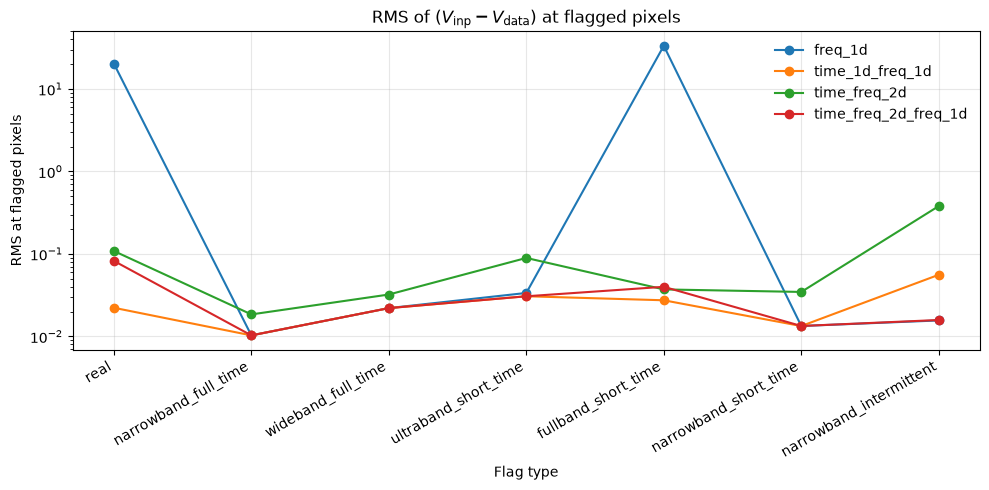

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for Algorithm_name in Algorithm_names:
    ax.plot(
        rms_table.index,
        rms_table[Algorithm_name],
        marker="o",
        label=Algorithm_name,
    )

ax.set_xlabel("Flag type")
ax.set_ylabel("RMS at flagged pixels")
ax.set_title("RMS of $(V_{\\rm inp} - V_{\\rm data})$ at flagged pixels")
ax.grid(True, alpha=0.3)

# 如果动态范围很大，建议打开 log
ax.set_yscale("log")

plt.xticks(rotation=30, ha="right")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()